#**1.Import Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Why:** Loads the rquired libraries for data handling and visualization throughout the project.

#**2.Mount Drive & Load Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Crop_recommendation.csv')

Mounted at /content/drive


**Why:** Connects Google Drive to Colab and loads the CSV dataset into a DataFrame.

#**3.Define Season Logic & Create Season Column**

In [6]:
def get_Season(temp, rainfall):
   if temp >= 30 and rainfall >= 150:
      return 'Rainy'
   elif temp >=25 and rainfall <150:
       return 'Summer'
   elif temp < 15:
       return 'Winter'
   else:
       return 'Spring'

data['Season'] = data.apply(lambda row: get_Season(row['temperature'], row['rainfall']), axis=1)

print(data['Season'].value_counts())

Season
Spring    1130
Summer     981
Rainy       48
Winter      41
Name: count, dtype: int64


**Why:** Classifies each record into a season based on temperature and rainfall thresholds, then counts how many records fall into each season.

#**4.Visualize Seasonal Distribution**

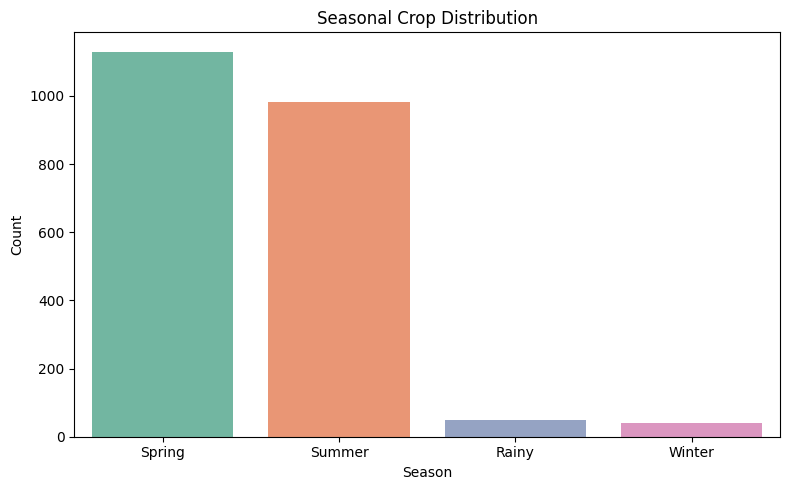

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='Season', data=data, palette='Set2', hue='Season', legend=False)
plt.title('Seasonal Crop Distribution')
plt.xlabel('Season')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('seasonal_crop_distribution.png')
plt.show()

**Why:** Displays a bar chart showing how many records fall into each season, and saves it as an image for documentation.

#**5.List Crops Per Season**

In [11]:
for Season in ['Summer', 'Winter', 'Rainy', 'Spring']:
    print(f"\n{Season} Crops:")
    print(data[data['Season'] == Season]['label'].unique())


Summer Crops:
['maize' 'pigeonpeas' 'mothbeans' 'mungbean' 'blackgram' 'lentil' 'banana'
 'mango' 'grapes' 'watermelon' 'muskmelon' 'orange' 'papaya' 'coconut'
 'cotton' 'coffee']

Winter Crops:
['grapes' 'orange']

Rainy Crops:
['pigeonpeas' 'papaya']

Spring Crops:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans' 'lentil'
 'pomegranate' 'grapes' 'watermelon' 'apple' 'orange' 'papaya' 'coconut'
 'cotton' 'jute' 'coffee']


**Why:** Identifies which specific crops are associated with each season based on the derived classification.

###**Conclusion:**
A new "**Season**" feature was successfully derived from temperature and rainfall, enabling crop recommendations to be grouped and analyzed by season.

 This module was completed by **Vani Vasantha Laxmi Yepparika** as part of the Data Preprocessing phase of the Opticrop Project focused on extracting seasonal crop information.